# Анализ данных (EDA)

Импорт библиотек

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc, classification_report
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Загрузка и базовая подготовка

In [2]:
current = Path.cwd().parents[1]
data_path = current / "data" / "raw" / "banking_transactions.csv"
df = pd.read_csv(data_path)

df.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [3]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes  

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,1.005000e+06,2886.895680,1000001.00,1002500.750,1005000.500,1.007500e+06,1010000.00
transaction_amount,10000.0,1.241275e+04,7200.700863,6.27,6174.025,12322.965,1.861965e+04,24997.52
login_attempts,10000.0,6.438900e+00,3.453558,1.00,3.000,6.000,9.000000e+00,12.00
device_risk_score,10000.0,5.025719e+01,29.414463,0.00,25.100,50.200,7.550000e+01,100.00
transfer_frequency,10000.0,3.964840e+01,23.419868,0.00,19.000,40.000,6.000000e+01,80.00
anomaly_score,10000.0,3.489160e-01,0.236890,0.01,0.170,0.310,4.800000e-01,0.99
account_age_days,10000.0,2.510241e+03,1436.335019,6.00,1271.750,2511.000,3.746250e+03,5000.00
transaction_time_hour,10000.0,1.155360e+01,6.962254,0.00,6.000,11.000,1.800000e+01,23.00
failed_transactions_last_30d,10000.0,1.243780e+01,7.532875,0.00,6.000,13.000,1.900000e+01,25.00
avg_monthly_balance,10000.0,2.493675e+05,144580.006647,104.16,122291.355,249799.800,3.731468e+05,499968.25


In [5]:
# Преобразование целевой переменной
df['fraud_flag'] = df['fraud_flag'].map({True: 1, False: 0})
df.set_index('transaction_id', inplace=True, verify_integrity=True)

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} признаков")
print(f"Типы данных:\n{df.dtypes.value_counts()}")
print(f"Пропуски: {df.isnull().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

Размер датасета: 10000 строк, 19 признаков
Типы данных:
int64      12
float64     5
object      2
Name: count, dtype: int64
Пропуски: transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
international_transaction_flag    0
suspicious_ip_flag                0
fraud_flag                        0
dtype: int64
Дубликаты: 0


#### Анализ целевой переменной


Доля мошеннических транзакций: 12.51%


Text(0, 0.5, 'Количество')

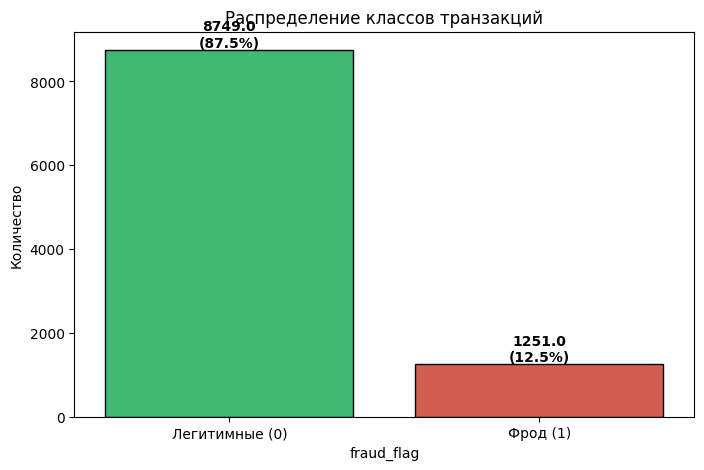

In [6]:
fraud_ratio = df['fraud_flag'].mean()
print(f"\nДоля мошеннических транзакций: {fraud_ratio:.2%}")

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='fraud_flag', data=df, palette=['#2ecc71', '#e74c3c'], 
                   order=[0, 1], edgecolor='black')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', fontweight='bold')
plt.xticks([0, 1], ['Легитимные (0)', 'Фрод (1)'])
plt.title('Распределение классов транзакций')
plt.ylabel('Количество')

fraud_label == 1 составляет ~12.5% от всех записей. Сильный imbalance.

**Вывод**: Нельзя использовать Accuracy. Обязательно: class_weight='balanced', StratifiedKFold, оптимизация по PR-AUC или F1. 

Порог классификации сместить от 0.5 в сторону меньшего (0.2–0.3) для повышения Recall.

#### Числовые признаки: распределение и корреляция


Топ-корреляции с fraud_flag:
anomaly_score                 0.674833
suspicious_ip_flag            0.009597
transaction_velocity_score    0.009562
transaction_amount            0.005417
session_duration_minutes      0.004646
card_present_flag             0.000911
transaction_time_hour         0.000236
login_attempts               -0.000968
device_risk_score            -0.001271
avg_monthly_balance          -0.001544
dtype: float64


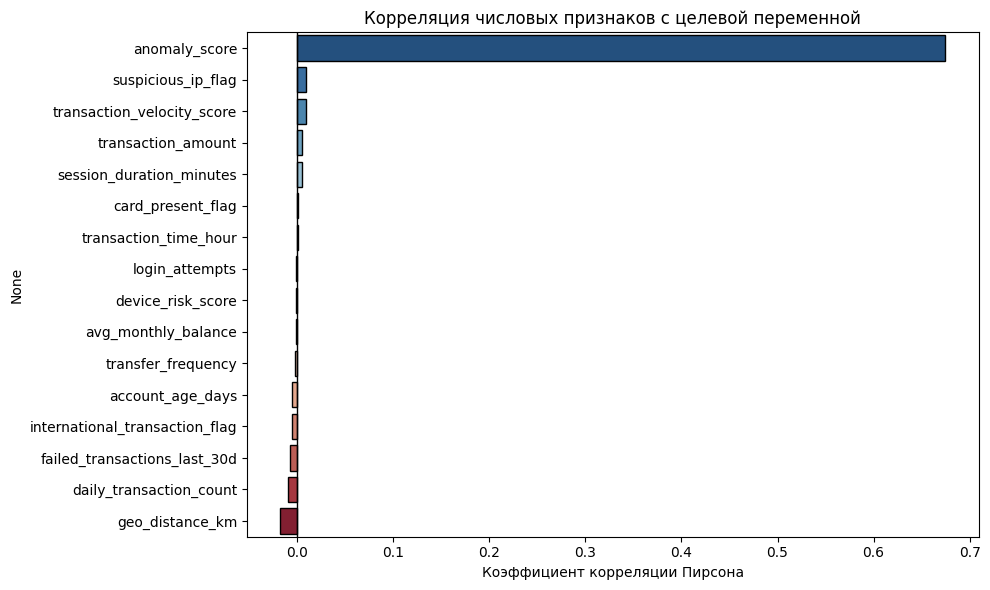

In [7]:
num_cols = df.select_dtypes(include='number').columns.drop('fraud_flag')

# Корреляция Пирсона с таргетом
corr_with_target = df[num_cols].corrwith(df['fraud_flag']).sort_values(ascending=False)
print("\nТоп-корреляции с fraud_flag:")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target, y=corr_with_target.index, 
            palette='RdBu_r', edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Корреляция числовых признаков с целевой переменной')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.tight_layout()


Топ-корреляции с fraud_flag:
anomaly_score                 0.547515
transaction_velocity_score    0.009641
suspicious_ip_flag            0.009597
transaction_amount            0.005331
session_duration_minutes      0.004699
card_present_flag             0.000911
transaction_time_hour         0.000290
login_attempts               -0.001030
device_risk_score            -0.001319
avg_monthly_balance          -0.001487
dtype: float64


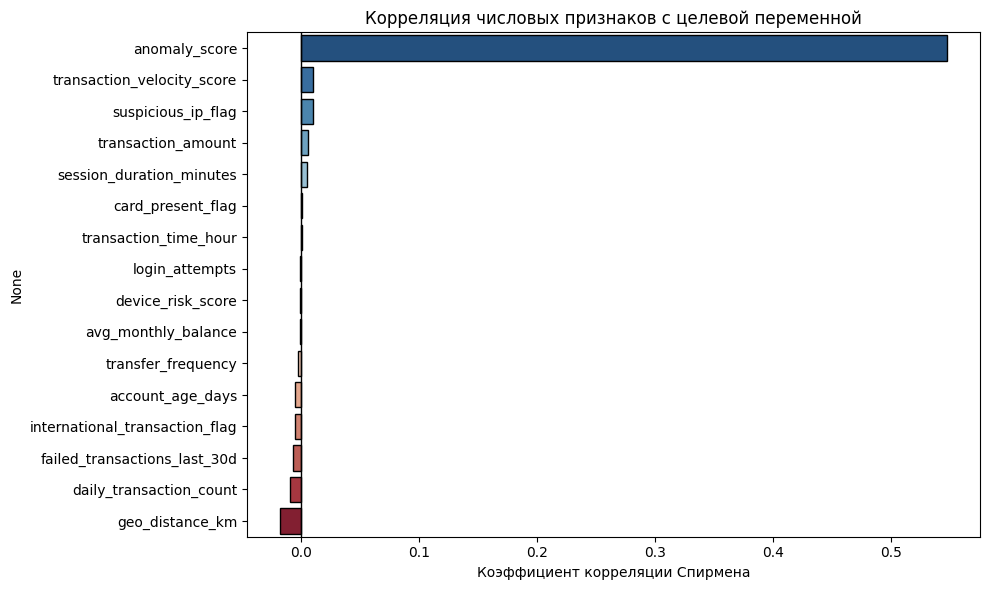

In [8]:
# Корреляция Спирмена с таргетом
corr_with_target = df[num_cols].corrwith(df['fraud_flag'], method='spearman').sort_values(ascending=False)

print("\nТоп-корреляции с fraud_flag:")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target, y=corr_with_target.index, 
            palette='RdBu_r', edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Корреляция числовых признаков с целевой переменной')
plt.xlabel('Коэффициент корреляции Спирмена')
plt.tight_layout()

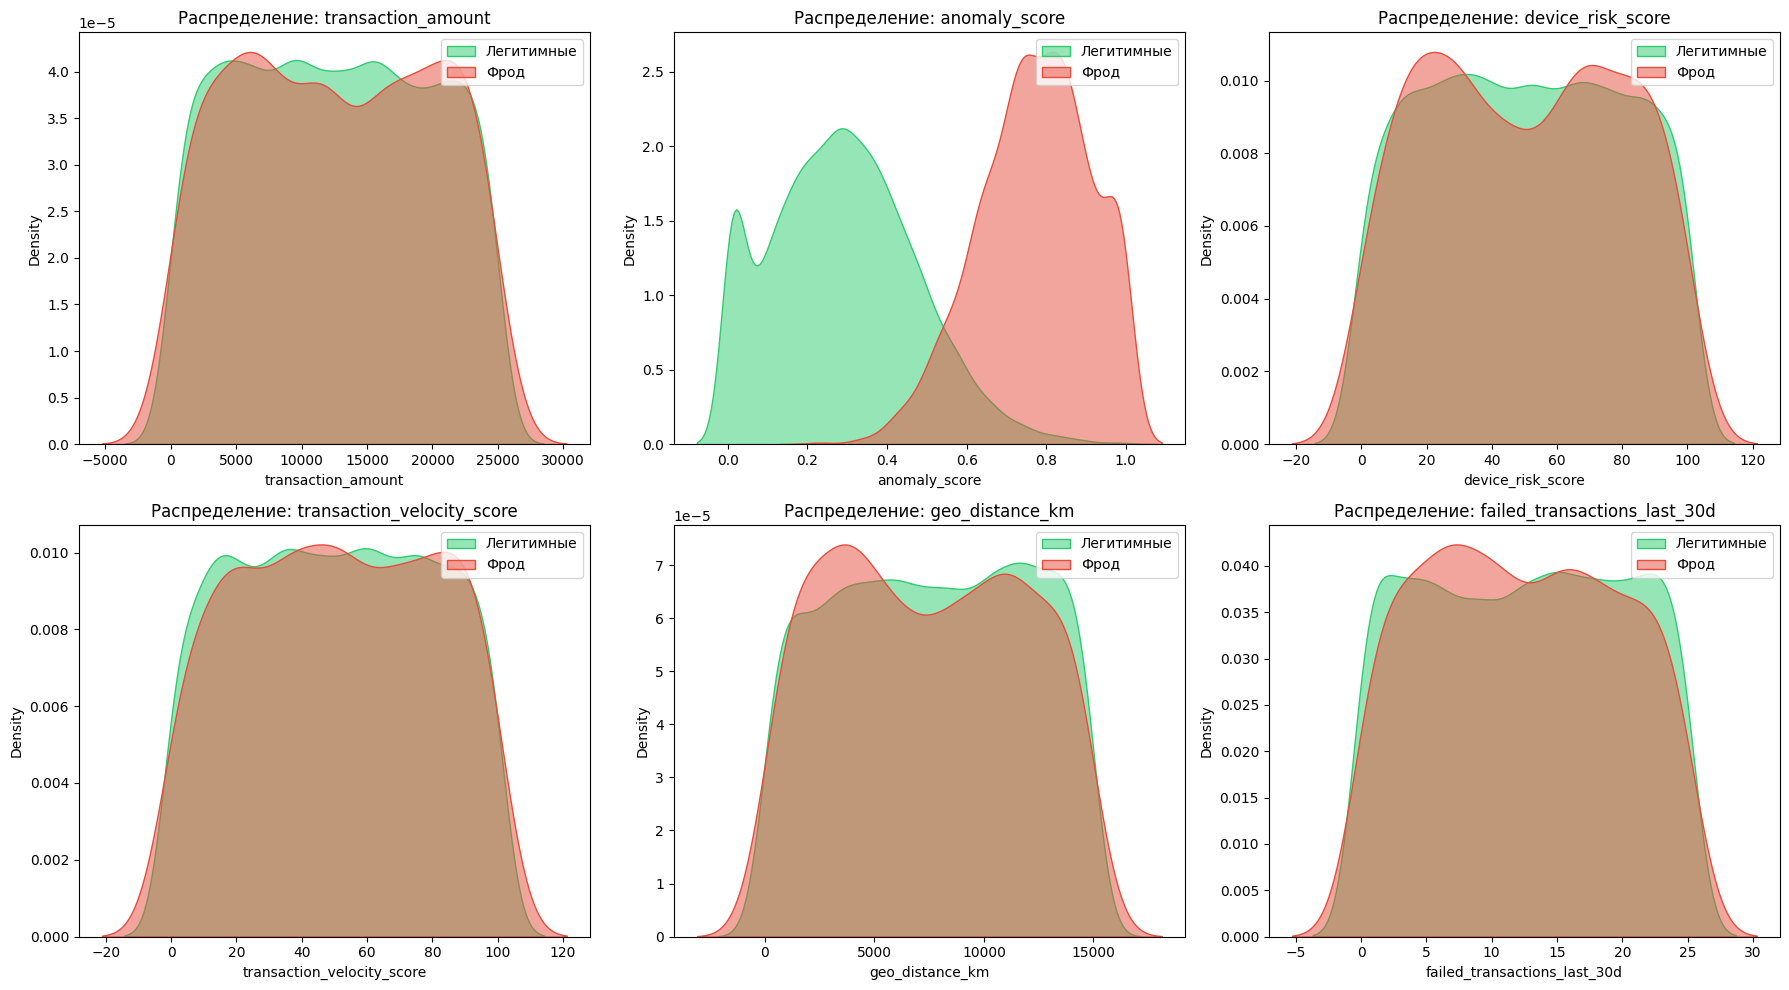

In [ ]:
# Визуализация ключевых признаков (логарифмирование для skew)
key_nums = ['transaction_amount', 'anomaly_score', 'device_risk_score', 
            'transaction_velocity_score', 'geo_distance_km', 'failed_transactions_last_30d']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_nums):
    # Разделение по классам
    legit = df[df['fraud_flag'] == 0][col]
    fraud = df[df['fraud_flag'] == 1][col]
    
    # Лог-трансформация для amount и geo_distance
    data_to_plot = [legit, fraud]
        
    sns.kdeplot(data_to_plot[0], ax=axes[i], color='#2ecc71', fill=True, alpha=0.5, label='Легитимные')
    sns.kdeplot(data_to_plot[1], ax=axes[i], color='#e74c3c', fill=True, alpha=0.5, label='Фрод')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

Признак 'anomaly_score' показывает сильную корреляцию с таргетом в сравнении с остальными признаками.

#### Категориальные признаки

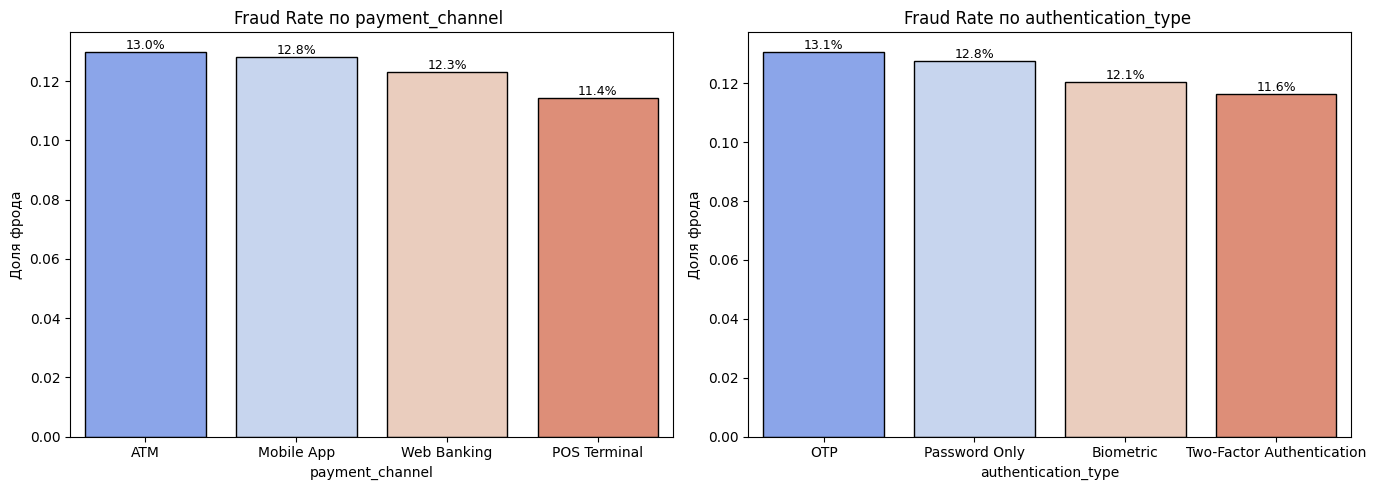

In [10]:
cat_cols = ['payment_channel', 'authentication_type']
bin_cols = ['card_present_flag', 'international_transaction_flag', 'suspicious_ip_flag']

def plot_fraud_rate_by_col(col, ax, title_suffix=""):
    rates = df.groupby(col)['fraud_flag'].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, ax=ax, palette='coolwarm', edgecolor='black')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width()/2, p.get_height()), 
                    ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Доля фрода')
    ax.set_title(f'Fraud Rate по {col} {title_suffix}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_fraud_rate_by_col('payment_channel', axes[0])
plot_fraud_rate_by_col('authentication_type', axes[1])
plt.tight_layout()

Наименьшая доля фрода среди **каналов проведения платежа (payment_channel)** у POS Terminal.

По сравнению с ней у Web Banking доля фрода выше на ~7,9%

У Mobile App доля фрода выше на ~12,3%

у ATM доля фрода выше на ~14%

Наименьшая доля фрода среди разных типов **аутентификации (authentication_type)** у двуфакторной Two-Factor Authentication.

По сравнению с ней у Biometric доля фрода выше на ~4,3%

У Password Only доля фрода выше на ~10,3%

у OTP доля фрода выше на ~12%

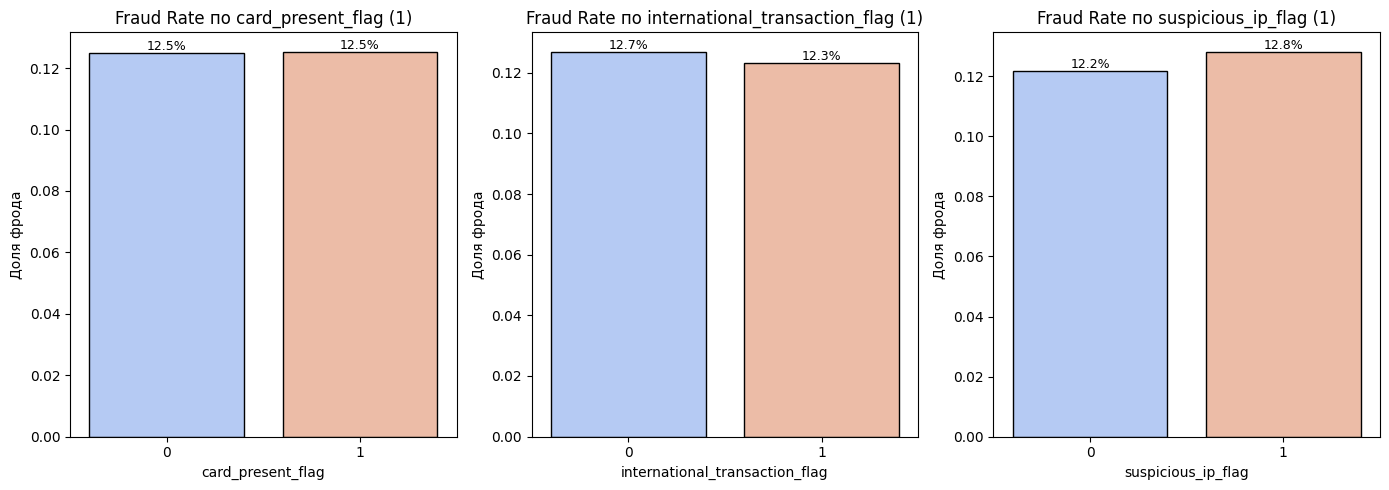

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(bin_cols):
    plot_fraud_rate_by_col(col, axes[i], title_suffix=f"({'1' if col.endswith('_flag') else 'да/нет'})")
plt.tight_layout()

Доля фрода в признаке 'card_present_flag' (индикатор использования физической карты при транзакции) распределена равномерно.

В признаке 'international_transaction_flag' (индикатор трансграничного характера операции) доля фрода на ~3,2% выше при операциях внутри страны.

В признаке 'suspicious_ip_flag' (индикатор входа с подозрительного или анонимного IP-адреса) доля фрода на ~5% выше при входе с подозрительного IP.

#### Временные и поведенческие паттерны

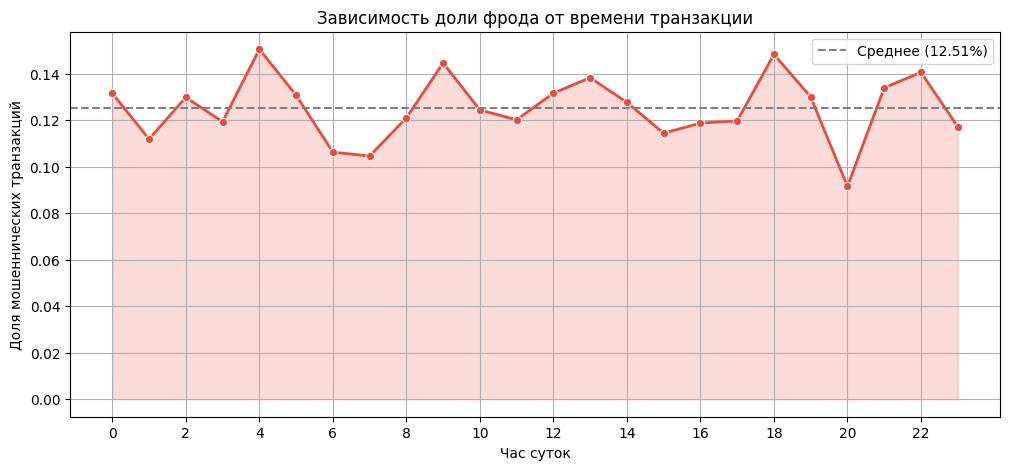

In [12]:
# Час транзакции
hourly_fraud = df.groupby('transaction_time_hour')['fraud_flag'].mean()
plt.figure(figsize=(12, 5))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values, marker='o', color='#e74c3c', linewidth=2)
plt.fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.2, color='#e74c3c')
plt.axhline(y=fraud_ratio, color='gray', linestyle='--', label=f'Среднее ({fraud_ratio:.2%})')
plt.xticks(range(0, 24, 2))
plt.xlabel('Час суток')
plt.ylabel('Доля мошеннических транзакций')
plt.title('Зависимость доли фрода от времени транзакции')
plt.legend()
plt.grid(True)

Наибольшие часы фрода (Доля фрода >= ~0,14) - 04:00, 09:00, 13:00, 18:00, 21:00, 22:00 

Комбинированный анализ: Geo Distance + Velocity

Text(0.5, 1.0, 'Паттерн: Гео-расстояние vs Скорость транзакций')

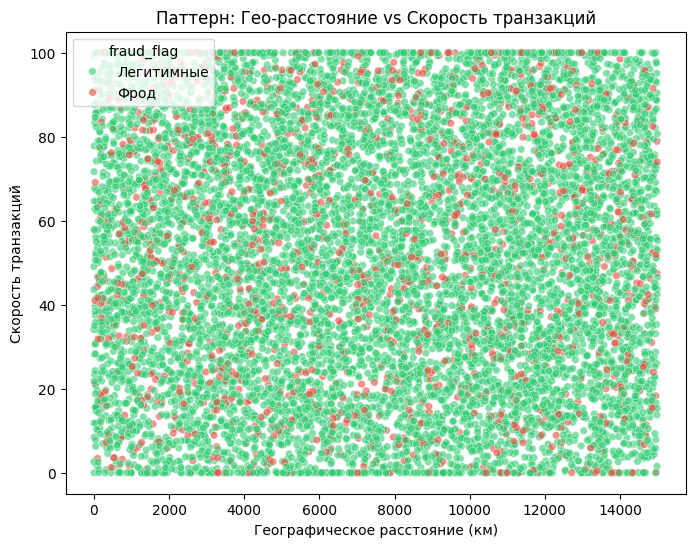

In [14]:
plt.figure(figsize=(8, 6))
scatter_data = df[['geo_distance_km', 'transaction_velocity_score', 'fraud_flag']].copy()
scatter_data['fraud_flag'] = scatter_data['fraud_flag'].map({1: 'Фрод', 0: 'Легитимные'})
sns.scatterplot(data=scatter_data, x='geo_distance_km', y='transaction_velocity_score', 
                hue='fraud_flag', alpha=0.6, palette=['#2ecc71', '#e74c3c'], s=30)
plt.xlabel('Географическое расстояние (км)')
plt.ylabel('Скорость транзакций')
plt.title('Паттерн: Гео-расстояние vs Скорость транзакций')

Распределение по географическому признаку равномерно.

#### Baseline модель

Построены две baseline-модели бустинга с помощью LightGBM для сравнения влияния признаков на качество модели, так как их корреляция с таргетом слабая.

Первая модель обучена на одном лишь признаке "anomaly_score", который имеет самую значительную корреляцию с таргетом.

Вторая модель помимо "anomaly_score" также включает остальные признаки.

In [25]:
# ==========================================
# ПОДГОТОВКА ПРИЗНАКОВ
# ==========================================

# Определяем целевую переменную
target = 'fraud_flag'

# Исключаем ID и таргет из признаков
exclude_cols = ['transaction_id', target]
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Находим все колонки с типом object и преобразуем их в category
object_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()

# Преобразуем строковые колонки в категориальные
for col in object_cols:
    df[col] = df[col].astype('category')

# Теперь все строковые колонки стали категориальными
cat_features = object_cols  

X = df[feature_cols]
y = df[target]

# ==========================================
# ФУНКЦИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ
# ==========================================
def cross_val_metrics(model, X, y, cat_features, model_name, n_folds=5):
    """Выполняет кросс-валидацию и возвращает метрики с classification report"""
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Собираем предсказания по всем фолдам
    all_y_true = []
    all_y_pred = []
    all_y_pred_proba = []
    
    roc_auc_scores = []
    f1_scores = []
    pr_auc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]
        
        # Копируем модель для каждого фолда
        model_fold = lgb.LGBMClassifier(**model.get_params())
        model_fold.fit(
            X_train_fold, 
            y_train_fold,
            categorical_feature=cat_features
        )
        
        y_pred_proba = model_fold.predict_proba(X_val_fold)[:, 1]
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # Сохраняем для итогового отчета
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_pred_proba.extend(y_pred_proba.tolist())
        
        # Метрики
        roc_auc = roc_auc_score(y_val_fold, y_pred_proba)
        f1 = f1_score(y_val_fold, y_pred)
        precision, recall, _ = precision_recall_curve(y_val_fold, y_pred_proba)
        pr_auc = auc(recall, precision)
        
        roc_auc_scores.append(roc_auc)
        f1_scores.append(f1)
        pr_auc_scores.append(pr_auc)
    
    # Вывод результатов
    print(f"\n{model_name}")
    print("="*50)
    print(f"ROC-AUC: {np.mean(roc_auc_scores):.4f}")
    print(f"F1-Score: {np.mean(f1_scores):.4f}")
    print(f"PR-AUC: {np.mean(pr_auc_scores):.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Fraud']))
    
    return {
        'roc_auc': np.mean(roc_auc_scores),
        'roc_auc_std': np.std(roc_auc_scores),
        'f1': np.mean(f1_scores),
        'f1_std': np.std(f1_scores),
        'pr_auc': np.mean(pr_auc_scores),
        'pr_auc_std': np.std(pr_auc_scores)
    }

# ==========================================
# БАЗОВАЯ МОДЕЛЬ 1: ТОЛЬКО anomaly_score
# ==========================================
features_b1 = ['anomaly_score']
X_b1 = X[features_b1]

params_b1 = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'is_unbalance': True,
    'random_state': 42,
    'n_estimators': 100
}

model_b1 = lgb.LGBMClassifier(**params_b1)
results_b1 = cross_val_metrics(model_b1, X_b1, y, [], "BASELINE 1: LightGBM на признаке 'anomaly_score'")

# ==========================================
# БАЗОВАЯ МОДЕЛЬ 2: ВСЕ ПРИЗНАКИ
# ==========================================
params_b2 = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'is_unbalance': True,
    'random_state': 42,
    'n_estimators': 200
}

model_b2 = lgb.LGBMClassifier(**params_b2)
results_b2 = cross_val_metrics(model_b2, X, y, cat_features, "BASELINE 2: LightGBM на всех признаках")

# ==========================================
# СРАВНЕНИЕ
# ==========================================
print("\n" + "="*50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*50)
print(f"Baseline 1 (anomaly_score) ROC-AUC: {results_b1['roc_auc']:.4f}")
print(f"Baseline 2 (All Features)  ROC-AUC: {results_b2['roc_auc']:.4f}")
print(f"Прирост ROC-AUC: {(results_b2['roc_auc'] - results_b1['roc_auc']):.4f}")

print(f"\nBaseline 1 (anomaly_score) F1-Score: {results_b1['f1']:.4f}")
print(f"Baseline 2 (All Features)  F1-Score: {results_b2['f1']:.4f}")
print(f"Прирост F1-Score: {(results_b2['f1'] - results_b1['f1']):.4f}")


BASELINE 1: LightGBM на признаке 'anomaly_score'
ROC-AUC: 0.9756
F1-Score: 0.7288
PR-AUC: 0.8538

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.91      0.95      8749
       Fraud       0.60      0.94      0.73      1251

    accuracy                           0.91     10000
   macro avg       0.79      0.92      0.84     10000
weighted avg       0.94      0.91      0.92     10000


BASELINE 2: LightGBM на всех признаках
ROC-AUC: 0.9739
F1-Score: 0.7921
PR-AUC: 0.8410

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      8749
       Fraud       0.74      0.85      0.79      1251

    accuracy                           0.94     10000
   macro avg       0.86      0.91      0.88     10000
weighted avg       0.95      0.94      0.95     10000


СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Baseline 1 (anomaly_score) ROC-AUC: 0.9756
Baseline 2 (All Features)  ROC-AUC: 0.9739
При

**Precision (Fraud)** у Baseline 2 увеличился на **+0.14 (~+23%)** для класса Fraud по сравнению с Baseline 1. **F1-score** общий также увеличился на **+0.063 (~+9%)**

Однако это повлекло снижение **Recall** для класса Fraud на **-0.09 (~-10%)**

**Дополнительные признаки (транзакции, геолокация, устройства)** помогают отсеять ложные срабатывания, которые генерирует **anomaly_score**.

Пример:

anomaly_score = 0.8 (подозрительно)

Но: device_risk_score низкий, geo_distance_km маленькая, daily_transaction_count нормальный

→ Ложная тревога отменяется

Дополнительные признаки "успокаивают" модель - она перестаёт бить тревогу по пограничным случаям, ждёт больше подтверждений.

Однако **Recall** становится меньше.

**Для бизнеса**:	Меньше ложных блокировок → довольные клиенты

**Вывод**: Использовать модель, включающую все признаки.

## Feature Engeenering

Создание новых признаков

**Временные признаки (на основе transaction_time_hour)**:

- Категоризация по часам с высоким/низким фродом (**is_high_risk_hour**), которую уже выявили (True для 04,09,13,18,21,22).

- **is_night_transaction** (02:00 - 06:00) – часто признак рисковой активности.

- **is_business_hours** (09:00 - 18:00) – добавление контекста нормы.

**Аггрегатные (поведенческие) признаки**:

Создадим признаки, которые характеризуют каждую конкретную транзакцию в контексте других признаков:

- **balance_to_amount_ratio**: 

avg_monthly_balance / (transaction_amount + epsilon) – показывает, насколько сумма перевода критична для среднего баланса пользователя. Аномально большие переводы могут быть фродом.

- **failed_attempts_to_frequency**: 

failed_transactions_last_30d / (transfer_frequency + epsilon) – отношение неудачных попыток к частоте переводов. Высокое значение может указывать на взлом или тестирование карты.

- **session_intensity**: 

transaction_velocity_score / (session_duration_minutes + epsilon) – интенсивность транзакций во время сессии (если сессия короткая, а скорость высокая – это подозрительно).

**Взаимодействие категориальных признаков**:

**channel_auth_risk** = payment_channel + "_" + authentication_type. 

Комбинация может дать синергетический эффект (например, "Web Banking" + "Password Only" могут быть намного рискованнее, чем "Mobile App" + "Biometric").

**Признаки на основе флагов**:

**suspicious_geo_sum** = suspicious_ip_flag + international_transaction_flag (оба косвенно про местоположение/сетевую аномалию)

Также необоходимо добавить: 

- Циклическое кодирование часа (для улавливания близости 23 и 0 часов): 

sin/cos * (2π * transaction_time_hour / 24)

- Использовать np.log1p для положительных асимметричных признаков:  

transaction_amount, geo_distance_km

Создаём признаки:

In [22]:
# Создаем копию для feature engineering, чтобы не испортить исходные данные
df_fe = df.copy()

# Масштабирование
# Используем np.log1p для положительных асимметричных признаков
df_fe['transaction_amount_log'] = np.log1p(df_fe['transaction_amount'])
df_fe['geo_distance_km_log'] = np.log1p(df_fe['geo_distance_km'])


# Временные признаки
# Часы с повышенной долей фрода
high_risk_hours = [4, 9, 13, 18, 21, 22]

df_fe['is_high_risk_hour'] = df_fe['transaction_time_hour'].isin(high_risk_hours).astype(int)
df_fe['is_night_transaction'] = df_fe['transaction_time_hour'].between(2, 6).astype(int)
df_fe['is_business_hours'] = df_fe['transaction_time_hour'].between(9, 18).astype(int)

# Циклическое кодирование часа (для улавливания близости 23 и 0 часов)
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['transaction_time_hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['transaction_time_hour'] / 24)


# Отношения и комбинации
# Соотношение баланса к сумме транзакции (защита от деления на ноль)
epsilon = 1e-6
df_fe['balance_to_amount_ratio'] = df_fe['avg_monthly_balance'] / (df_fe['transaction_amount'] + epsilon)
# Логирование, чтобы уменьшить влияние выбросов
df_fe['balance_to_amount_ratio_log'] = np.log1p(df_fe['balance_to_amount_ratio'])

# Неудачные попытки на частоту переводов
df_fe['failed_to_frequency'] = df_fe['failed_transactions_last_30d'] / (df_fe['transfer_frequency'] + epsilon)

# Интенсивность сессии (скорость транзакций)
df_fe['session_intensity'] = df_fe['transaction_velocity_score'] / (df_fe['session_duration_minutes'] + epsilon)


# Комбинация канала и аутентификации (может быть сильным предиктором)
df_fe['channel_auth_risk'] = df_fe['payment_channel'].astype(str) + "_" + df_fe['authentication_type'].astype(str)

# Сумма подозрительных флагов (IP + международный)
df_fe['suspicious_geo_sum'] = df_fe['suspicious_ip_flag'] + df_fe['international_transaction_flag']



# Удаление старых признаков
df_fe = df_fe.drop(['transaction_amount', 'geo_distance_km'], axis=1)

# Проверка результата
print("Добавленные признаки:")
new_features = ['transaction_amount_log', 'geo_distance_km_log', 'is_high_risk_hour', 
                'is_night_transaction', 'is_business_hours', 'hour_sin', 'hour_cos',
                'balance_to_amount_ratio_log', 'failed_to_frequency', 'session_intensity',
                'channel_auth_risk', 'suspicious_geo_sum']

print(df_fe[new_features].head(3))
print("\nРазмер датафрейма после Feature Engineering:", df_fe.shape)

Добавленные признаки:
                transaction_amount_log  geo_distance_km_log  \
transaction_id                                                
1000001                       9.788638             8.067776   
1000002                       9.705209             6.733402   
1000003                       9.177744             8.278682   

                is_high_risk_hour  is_night_transaction  is_business_hours  \
transaction_id                                                               
1000001                         1                     0                  0   
1000002                         0                     0                  1   
1000003                         0                     1                  0   

                hour_sin  hour_cos  balance_to_amount_ratio_log  \
transaction_id                                                    
1000001        -0.500000  0.866025                     1.991229   
1000002        -0.965926 -0.258819                     2.110112   
100

#### Тестирование новых признаков

In [24]:
# Определяем целевую переменную
target = 'fraud_flag'

# ==========================================
# ИСХОДНЫЕ ДАННЫЕ (БЕЗ FEATURE ENGINEERING)
# ==========================================
print("="*60)
print("ПОДГОТОВКА ИСХОДНЫХ ДАННЫХ")
print("="*60)

exclude_cols = ['transaction_id', target]
feature_cols_original = [col for col in df.columns if col not in exclude_cols]

# Преобразуем object в category
object_cols = df[feature_cols_original].select_dtypes(include=['object']).columns.tolist()

df_original = df.copy()
for col in object_cols:
    df_original[col] = df_original[col].astype('category')

X_original = df_original[feature_cols_original]
y_original = df_original[target]
cat_features_original = object_cols

print(f"Исходные признаки: {X_original.shape[1]}")

# Подготовка для модели
exclude_cols_fe = ['transaction_id', target]
feature_cols_fe = [col for col in df_fe.columns if col not in exclude_cols_fe]

# Преобразуем object в category
object_cols_fe = df_fe[feature_cols_fe].select_dtypes(include=['object']).columns.tolist()

for col in object_cols_fe:
    df_fe[col] = df_fe[col].astype('category')

X_fe = df_fe[feature_cols_fe]
y_fe = df_fe[target]
cat_features_fe = object_cols_fe

print(f"Признаков после FE: {X_fe.shape[1]}")
print(f"Из них новых: {X_fe.shape[1] - X_original.shape[1]}")

# ==========================================
# ФУНКЦИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ
# ==========================================
def cross_val_metrics(model, X, y, cat_features, model_name, n_folds=5):
    """Выполняет кросс-валидацию и возвращает метрики с classification report"""
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Собираем предсказания по всем фолдам
    all_y_true = []
    all_y_pred = []
    all_y_pred_proba = []
    
    roc_auc_scores = []
    f1_scores = []
    pr_auc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]
        
        model_fold = lgb.LGBMClassifier(**model.get_params())
        model_fold.fit(
            X_train_fold, 
            y_train_fold,
            categorical_feature=cat_features
        )
        
        y_pred_proba = model_fold.predict_proba(X_val_fold)[:, 1]
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # Сохраняем для итогового отчета
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_pred_proba.extend(y_pred_proba.tolist())
        
        # Метрики для каждого фолда
        roc_auc = roc_auc_score(y_val_fold, y_pred_proba)
        f1 = f1_score(y_val_fold, y_pred)
        precision, recall, _ = precision_recall_curve(y_val_fold, y_pred_proba)
        pr_auc = auc(recall, precision)
        
        roc_auc_scores.append(roc_auc)
        f1_scores.append(f1)
        pr_auc_scores.append(pr_auc)
    
    # Итоговые метрики
    from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
    
    print(f"\n{model_name}")
    print("="*50)
    print(f"ROC-AUC: {np.mean(roc_auc_scores):.4f}")
    print(f"F1-Score: {np.mean(f1_scores):.4f}")
    print(f"PR-AUC: {np.mean(pr_auc_scores):.4f}")
    
    # Classification report на aggregated predictions
    print("\nClassification Report:")
    print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Fraud']))
    
    return {
        'roc_auc': np.mean(roc_auc_scores),
        'roc_auc_std': np.std(roc_auc_scores),
        'f1': np.mean(f1_scores),
        'f1_std': np.std(f1_scores),
        'pr_auc': np.mean(pr_auc_scores),
        'pr_auc_std': np.std(pr_auc_scores),
        'y_true': all_y_true,
        'y_pred': all_y_pred,
        'y_pred_proba': all_y_pred_proba
    }


# ==========================================
# БАЗОВАЯ МОДЕЛЬ 2: ВСЕ ИСХОДНЫЕ ПРИЗНАКИ
# ==========================================
params_b2 = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'is_unbalance': True,
    'random_state': 42,
    'n_estimators': 200
}

model_b2 = lgb.LGBMClassifier(**params_b2)
results_b2 = cross_val_metrics(model_b2, X_original, y_original, cat_features_original, "BASELINE 2: LightGBM на всех исходных признаках")

# ==========================================
# МОДЕЛЬ 3: ВСЕ ПРИЗНАКИ ПОСЛЕ FEATURE ENGINEERING
# ==========================================
model_b3 = lgb.LGBMClassifier(**params_b2)
results_b3 = cross_val_metrics(model_b3, X_fe, y_fe, cat_features_fe, "MODEL 3: LightGBM на всех признаках (после FE)")

# ==========================================
# СРАВНЕНИЕ ВСЕХ ТРЁХ МОДЕЛЕЙ
# ==========================================
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)
print(f"Baseline 2 (All Features)  ROC-AUC: {results_b2['roc_auc']:.4f}")
print(f"Model 3 (After FE)         ROC-AUC: {results_b3['roc_auc']:.4f}")
print(f"Прирост (FE vs Original): {(results_b3['roc_auc'] - results_b2['roc_auc']):.4f}")


print(f"Baseline 2 (All Features)  F1-Score: {results_b2['f1']:.4f}")
print(f"Model 3 (After FE)         F1-Score: {results_b3['f1']:.4f}")
print(f"Прирост (FE vs Original): {(results_b3['f1'] - results_b2['f1']):.4f}")


print(f"Baseline 2 (All Features)  PR-AUC: {results_b2['pr_auc']:.4f}")
print(f"Model 3 (After FE)         PR-AUC: {results_b3['pr_auc']:.4f}")
print(f"Прирост (FE vs Original): {(results_b3['pr_auc'] - results_b2['pr_auc']):.4f}")

ПОДГОТОВКА ИСХОДНЫХ ДАННЫХ
Исходные признаки: 18
Признаков после FE: 29
Из них новых: 11

BASELINE 2: LightGBM на всех исходных признаках
ROC-AUC: 0.9739
F1-Score: 0.7921
PR-AUC: 0.8410

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      8749
       Fraud       0.74      0.85      0.79      1251

    accuracy                           0.94     10000
   macro avg       0.86      0.91      0.88     10000
weighted avg       0.95      0.94      0.95     10000


MODEL 3: LightGBM на всех признаках (после FE)
ROC-AUC: 0.9729
F1-Score: 0.7886
PR-AUC: 0.8401

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      8749
       Fraud       0.74      0.85      0.79      1251

    accuracy                           0.94     10000
   macro avg       0.86      0.90      0.88     10000
weighted avg       0.95      0.94      0.94     10000


СРАВНЕНИЕ РЕЗУЛ

Создание новых признаков не принесло желаемого улучшения модели.

**Вывод**: использовать имеющиеся в датасете признаки, без добавления новых.